# Handling an Imbalanced Dataset Using SMOTE

## 1. What is an imbalanced dataset?

An **imbalanced dataset** is a dataset in which the classes contain noticeably different numbers of observations. For example, a dataset may contain many more observations from class `0` than from class `1`.

This notebook demonstrates how to:
1. Generate a sample imbalanced classification dataset.
2. Convert the features and target into a pandas DataFrame.
3. Inspect and visualize the class distribution.
4. Apply **SMOTE (Synthetic Minority Over-sampling Technique)** to balance the classes.
5. Compare the dataset before and after oversampling.

> **Important:** SMOTE creates synthetic minority-class examples. It does not simply duplicate existing minority-class rows.


## 2. Import the dataset generator

`make_classification()` from `sklearn.datasets` creates a synthetic dataset for classification practice.

- `n_samples=1000`: generate 1,000 observations.
- `n_features=2`: create two features.
- `n_redundant=0`: do not add redundant features.
- `n_clusters_per_class=1`: use one cluster per class.
- `weights=[0.9]`: request an approximately 90% / 10% class split.
- `random_state=42`: make the generated dataset reproducible.


In [3]:
from sklearn.datasets import make_classification

## 3. Generate the imbalanced dataset

The feature matrix is stored in `X`, and the target labels are stored in `y`. The target has two classes: `0` and `1`.

Because the dataset is generated randomly, the observed class counts may not be exactly 900 and 100.


In [4]:
X,y=make_classification(
    n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=42
)

## 4. Create a pandas DataFrame

We place the two feature columns (`f1` and `f2`) into one DataFrame and the target labels into another. `pd.concat(..., axis=1)` combines them side by side into a single DataFrame called `df`.


In [5]:
import pandas as pd

In [6]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
df=pd.concat([df1,df2],axis=1)
df.head()

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0


## 5. Check the class distribution

`value_counts()` counts the observations in each target class.

In this run:
- Class `0`: **896 observations**
- Class `1`: **104 observations**

Class `1` is the minority class, so the dataset is imbalanced.


In [7]:
df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

## 6. Visualize the original dataset

The scatter plot shows each observation using `f1` on the x-axis and `f2` on the y-axis. The color represents the target class.

This visualization helps us inspect how the two classes are distributed before applying SMOTE.


In [8]:
import matplotlib.pyplot as plt

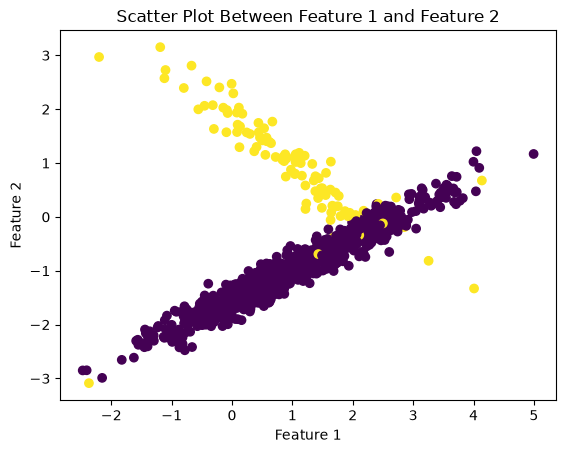

In [9]:
plt.scatter(df['f1'],df['f2'],c=df['target'])
plt.title("Scatter Plot Between Feature 1 and Feature 2")
plt.xlabel("Feature 1")
plt.ylabel('Feature 2')
plt.show()

## 7. Import SMOTE

`SMOTE` is provided by the `imbalanced-learn` package. It generates synthetic examples for the minority class using nearby minority-class observations.

If the package is not installed in your Python environment, install it with:

```python
pip install imbalanced-learn
```


In [10]:
from imblearn.over_sampling import SMOTE

## 8. Apply SMOTE

`fit_resample()` takes the feature columns and target labels, then returns a resampled feature matrix and target vector.

- `df[["f1", "f2"]]`: the two input features.
- `df["target"]`: the target labels.
- `X`: the resampled features.
- `y`: the resampled target labels.

With the default `sampling_strategy="auto"` for this binary classification task, SMOTE oversamples the minority class until it matches the majority class. Apply resampling only to the training data when building a predictive model; resampling the full dataset before splitting can cause data leakage.


In [ ]:
oversample=SMOTE()
X,y =oversample.fit_resample(df[["f1","f2"]],df['target'])

## 9. Check the resampled data

### Number of target labels

`y.shape` returns the dimensions of the resampled target vector. The result `(1792,)` means there are 1,792 target labels.

### Shape of the feature matrix

`X.shape` returns `(1792, 2)`: 1,792 observations and two features.

### Count the minority class

`len(y[y == 1])` counts the observations whose target label is `1`. After SMOTE, there are 896 observations in class `1`, matching the 896 observations in class `0`.


In [18]:
y.shape

(1792,)

In [17]:
X.shape

(1792, 2)

In [19]:
len(y[y==1])

896

## 10. Compare with the original class distribution

The following code checks `df`, which is the **original** DataFrame. Its counts remain 896 for class `0` and 104 for class `1` because SMOTE returned new resampled variables (`X` and `y`) rather than modifying `df` in place.


In [20]:
df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

## 11. Build a DataFrame from the resampled data

We convert the resampled features and labels back into a DataFrame named `oversample_df`. This makes it convenient to inspect or plot the balanced dataset.


In [24]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

## 12. Visualize the resampled dataset

This scatter plot shows the observations after SMOTE. Compare it with the original plot to see how the minority class has been expanded.

SMOTE balances the class counts, but a balanced dataset does not automatically guarantee a better model. Model performance should be evaluated on a separate, untouched test set using appropriate metrics.


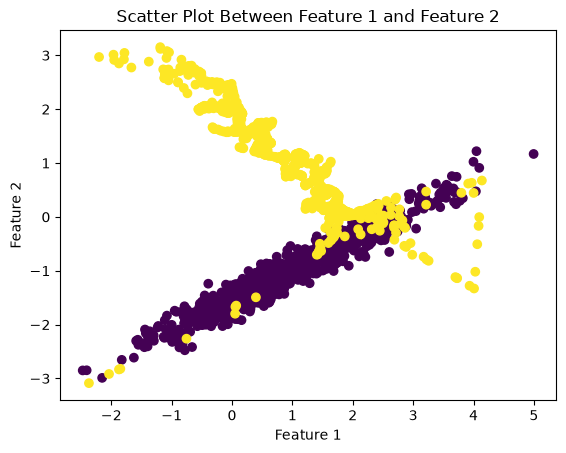

In [25]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])
plt.title("Scatter Plot Between Feature 1 and Feature 2")
plt.xlabel("Feature 1")
plt.ylabel('Feature 2')
plt.show()

## 13. Key takeaways

- The original dataset contained **1,000 observations**: 896 in class `0` and 104 in class `1`.
- SMOTE increased the minority class from 104 to 896 observations.
- The resampled dataset contains **1,792 observations**: 896 in each class.
- `df` still contains the original data; the resampled data are stored in `X`, `y`, and `oversample_df`.
- For machine-learning workflows, split the data first, apply SMOTE only to the training set, and evaluate on the original-distribution test set.
